# Import data

## Import player position/rotation data
Read from .json and build dataframe

In [ ]:
import json
import pandas as pd
import datetime as dt

FILENAME = "../data/savefile_01_pos_rot.json"
 
# 1. Load the raw JSON
with open(FILENAME, mode="r") as file:
    json_data: json = json.load(file)

# 2. Extract top-level metadata
player_id: str = json_data["playerId"]
save_time: dt.datetime = dt.datetime.strptime(json_data["saveDateTime"], "%Y-%m-%d %H:%M:%S")

# 3. Build rows from the list, reshaping position/rotation into tuples
rows = []
for entry in json_data["playerSaveObjectList"]:
    rows.append({
        "time":      entry["gametimer"],
        "position":  (entry["position"]["x"], entry["position"]["y"], entry["position"]["z"]),
        "rotation":  (entry["rotation"]["x"], entry["rotation"]["y"], entry["rotation"]["z"]),
        "playerId":  player_id,
        "saveTime":  save_time,
    })

# 4. Create the DataFrame
df = pd.DataFrame(rows)

x_list =  [x for (x,y,z) in df["position"]]
z_list =  [z for (x,y,z) in df["position"]]
rot_y_list = [y for (x,y,z) in df["rotation"]]
t_list: list[float] = [_ for _ in df["time"]]

print(df.head())
print("-----------")
print(df.dtypes)

       time           position                        rotation playerId  \
0  5.528239  (90.0, 0.0, 60.0)   (0.0, 46.83423614501953, 0.0)   id_001   
1  6.530888  (90.0, 0.0, 60.0)  (0.0, 107.00001525878906, 0.0)   id_001   
2  7.531301  (90.0, 0.0, 60.0)   (0.0, 95.61361694335938, 0.0)   id_001   
3  8.531610  (90.0, 0.0, 60.0)   (0.0, 95.61361694335938, 0.0)   id_001   
4  9.531744  (90.0, 0.0, 60.0)   (0.0, 87.09896087646484, 0.0)   id_001   

             saveTime  
0 2026-07-26 20:11:07  
1 2026-07-26 20:11:07  
2 2026-07-26 20:11:07  
3 2026-07-26 20:11:07  
4 2026-07-26 20:11:07  
-----------
time               float64
position            object
rotation            object
playerId               str
saveTime    datetime64[us]
dtype: object


## Import building data
Read from .json and import as Dataframe

In [ ]:
BUILDING_FILENAME: str = "../data/buildings.json"
buildings_data: pd.DataFrame = pd.read_json(BUILDING_FILENAME).set_index("building_id")

# Model with charts

## Map configuration for Level 1

In [43]:
# MAP SIZE
GRID_COLS: int = 6
GRID_ROWS: int = 5
BLOCK_SIZE: int = 30

# The extent is computed — maps pixel corners to world coordinates
map_extent = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_x_offset = BLOCK_SIZE / 2
map_z_offset = BLOCK_SIZE / 2

map_coord = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_coord[0] += map_x_offset  # left
map_coord[1] += map_x_offset  # right
map_coord[2] += map_z_offset  # bottom
map_coord[3] += map_z_offset  # top

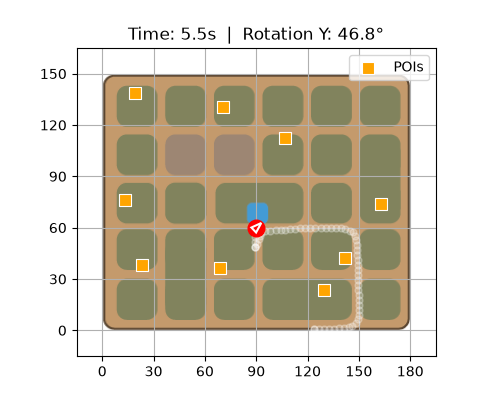

In [ ]:
%matplotlib widget
import ipywidgets as widgets
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.image as mpimg
import numpy as np




fig, ax = plt.subplots(figsize=(5,4))

# Add map image
MAP_IMAGE = "../images/map_level1.png"
map = mpimg.imread(MAP_IMAGE)
ax.imshow(map, extent=map_coord, origin="upper", aspect="equal")

# Plot all dots faded as a trail
trail, = ax.plot(x_list, z_list, 'o', color='white', alpha=0.25, markersize=5)

# Active path up to current time
path, = ax.plot([], [], '-o', color='cyan', markersize=4, linewidth=1)

# Current position marker
current, = ax.plot([], [], 'o', color='red', markersize=12, zorder=10)

ax.scatter(
    buildings_data["world_pos_x"],
    buildings_data["world_pos_z"],
    marker='s',        # squares to distinguish from player dots
    c='orange',
    s=80,
    edgecolors='white',
    linewidths=0.8,
    zorder=6,
    label='POIs'
)

ax.set_title("Player Position over Time")

ticks = np.arange(0,map_extent[1],30)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.legend()
ax.set_xlim(map_extent[0], map_extent[1])
ax.set_ylim(map_extent[2], map_extent[3])


plt.grid()

SIZE = 4
base_triangle = np.array([
    [0, SIZE],
    [-SIZE/2, -SIZE/2],
    [SIZE/2, -SIZE/2],
])

CENTER_X = 90
CENTER_Z = 60

tri_patch = Polygon(base_triangle, closed=True, fc='red', ec='white', lw=1.5, zorder=11)
tri_patch.set_visible(False)  # hidden until first slider move
#current marker has zorder=10, the triangle has zorder=11. Higher zorder draws on top.
#tri_patch.set_zorder(15)
ax.add_patch(tri_patch)

# Must redefine — the old update doesn't know about tri_patch
def update(frame):
    path.set_data(x_list[:frame+1], z_list[:frame+1])
    current.set_data([x_list[frame]], [z_list[frame]])
    

    # Triangle one frame ahead
    next_frame = min(frame + 1, len(x_list) - 1)
    angle = -rot_y_list[frame]
    rad = np.radians(angle)
    cos_a, sin_a = np.cos(rad), np.sin(rad)
    rotated = np.array([
        [v[0]*cos_a - v[1]*sin_a, v[0]*sin_a + v[1]*cos_a]
        for v in base_triangle
    ])
    rotated[:, 0] += x_list[next_frame]
    rotated[:, 1] += z_list[next_frame]
    tri_patch.set_xy(rotated)
    tri_patch.set_visible(True)

    ax.set_title(f"Time: {t_list[frame]:.1f}s  |  Rotation Y: {rot_y_list[frame]:.1f}°")
    fig.canvas.draw_idle()

# Widgets
play = widgets.Play(value=0, min=0, max=len(x_list)-1, step=1, interval=100)
slider = widgets.IntSlider(min=0, max=len(x_list)-1, step=1, value=0, description="Frame")
widgets.jslink((play, 'value'), (slider, 'value'))
ui = widgets.HBox([play, slider])
widgets.interactive_output(update, {'frame': slider})
display(ui)